In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [2]:

df = pd.read_csv('../data/processed/punjab_food_prices_merged.csv', parse_dates=['date'])

print(df.shape)
df.describe()

(103, 6)


,date,rice_price,sugar_price,wheat_price,rainfall_mm,temp_c
count,103,103.000000,103.000000,103.000000,103.000000,103.000000
mean,2017-04-01 05:49:30.873786368,76.531456,64.725340,39.179660,49.438835,23.891888
min,2013-01-01 00:00:00,56.285000,51.195000,32.625000,0.000000,11.116129
25%,2015-02-15 00:00:00,73.452500,54.132500,37.072500,11.050000,17.492540
50%,2017-04-01 00:00:00,77.545000,59.995000,38.450000,23.700000,25.640000
75%,2019-05-16 12:00:00,81.380000,71.442500,40.392500,74.600000,30.511129
max,2021-07-01 00:00:00,93.455000,102.655000,54.105000,258.700000,34.491667
std,NaN,7.758472,13.770542,3.728702,56.108856,7.234157


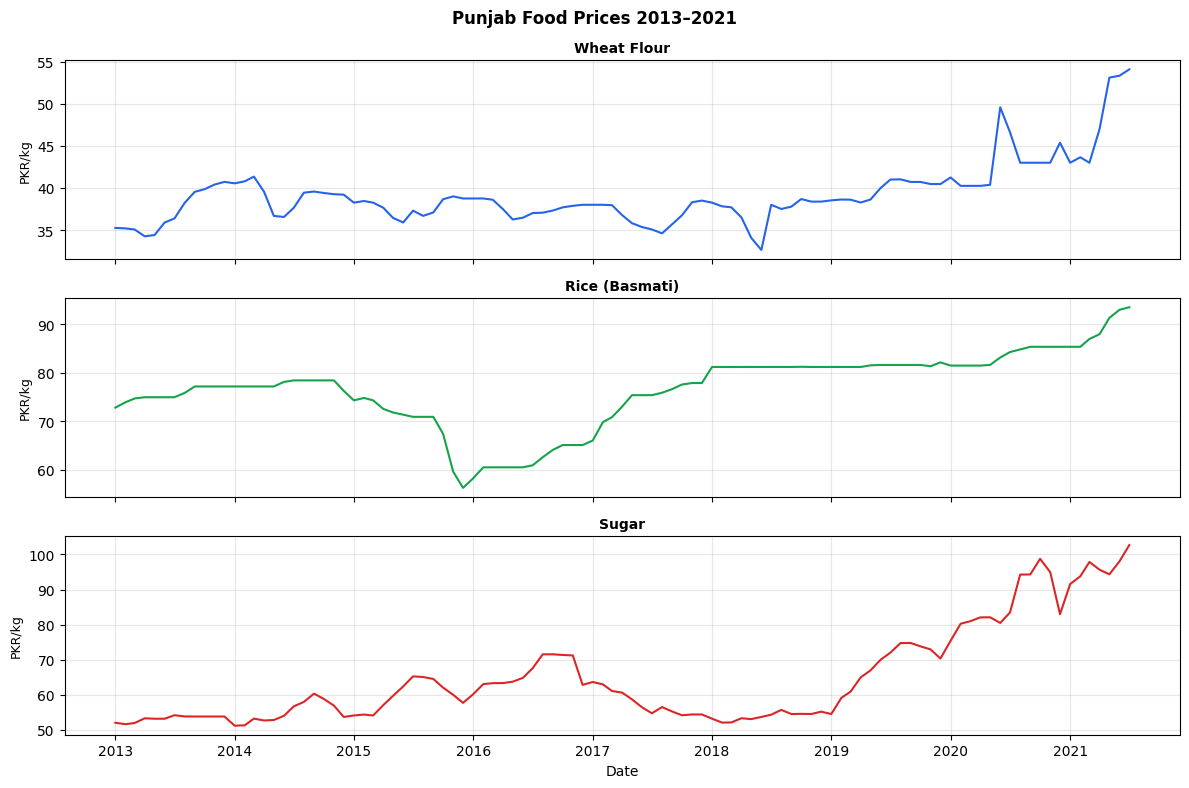

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

commodities = [
    ('wheat_price', 'Wheat Flour', '#2563EB'),
    ('rice_price',  'Rice (Basmati)', '#16A34A'),
    ('sugar_price', 'Sugar', '#DC2626')
]

for ax, (col, label, color) in zip(axes, commodities):
    ax.plot(df['date'], df[col], color=color, linewidth=1.5)
    ax.set_ylabel('PKR/kg', fontsize=9)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
fig.suptitle('Punjab Food Prices 2013–2021', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/price_trends.png', dpi=150, bbox_inches='tight')
plt.show()

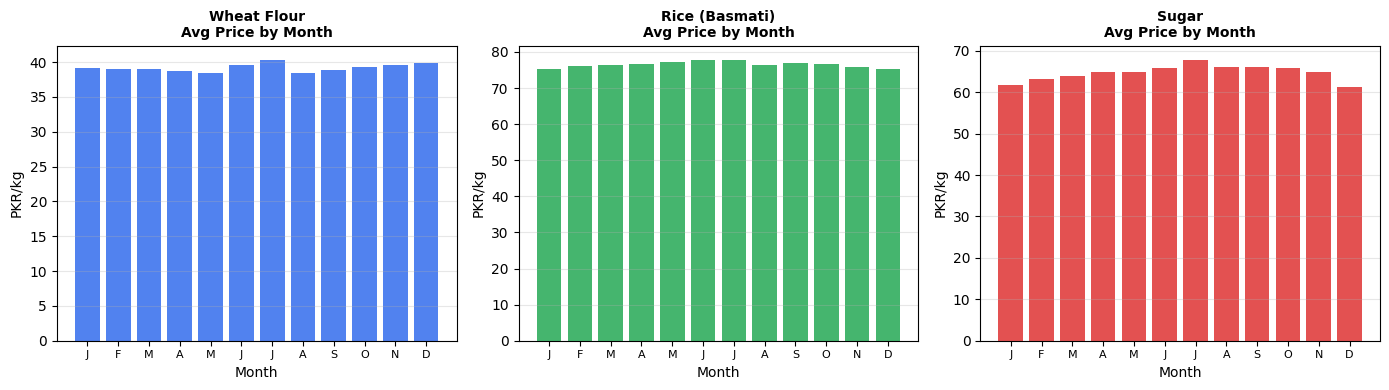

In [4]:
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

commodities = [
    ('wheat_price', 'Wheat Flour', '#2563EB'),
    ('rice_price', 'Rice (Basmati)', '#16A34A'),
    ('sugar_price', 'Sugar', '#DC2626')
]

for ax, (col, label, color) in zip(axes, commodities):
    monthly_avg = df.groupby('month')[col].mean()
    ax.bar(monthly_avg.index, monthly_avg.values, color=color, alpha=0.8)
    ax.set_title(f'{label}\nAvg Price by Month', fontsize=10, fontweight='bold')
    ax.set_xlabel('Month')
    ax.set_ylabel('PKR/kg')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'], fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../outputs/seasonality_by_month.png', dpi=150, bbox_inches='tight')
plt.show()

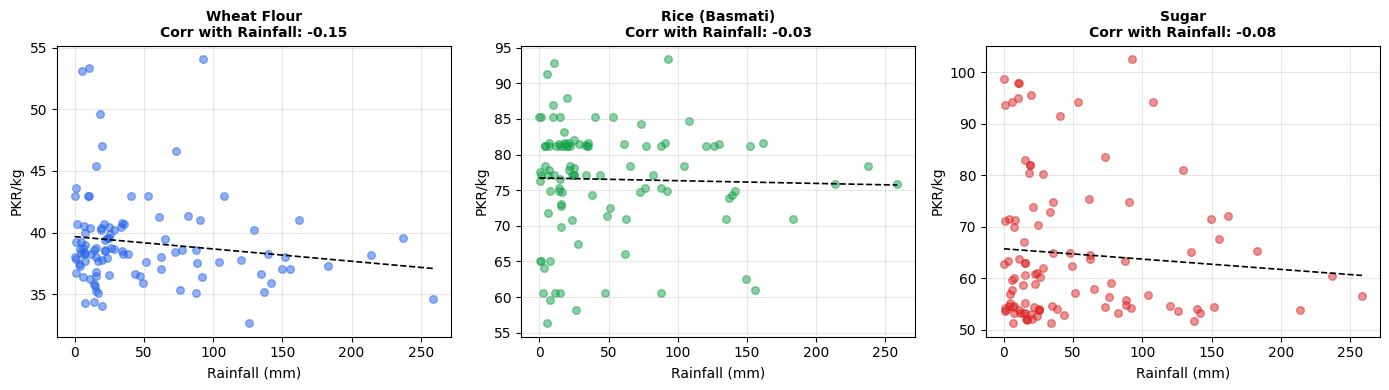

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

commodities = [
    ('wheat_price', 'Wheat Flour', '#2563EB'),
    ('rice_price', 'Rice (Basmati)', '#16A34A'),
    ('sugar_price', 'Sugar', '#DC2626')
]

for ax, (col, label, color) in zip(axes, commodities):
    ax.scatter(df['rainfall_mm'], df[col], alpha=0.5, color=color, s=30)
    # Add trend line
    z = np.polyfit(df['rainfall_mm'], df[col], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df['rainfall_mm'].min(), df['rainfall_mm'].max(), 100)
    ax.plot(x_line, p(x_line), color='black', linewidth=1.2, linestyle='--')
    corr = df['rainfall_mm'].corr(df[col])
    ax.set_title(f'{label}\nCorr with Rainfall: {corr:.2f}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Rainfall (mm)')
    ax.set_ylabel('PKR/kg')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/rainfall_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

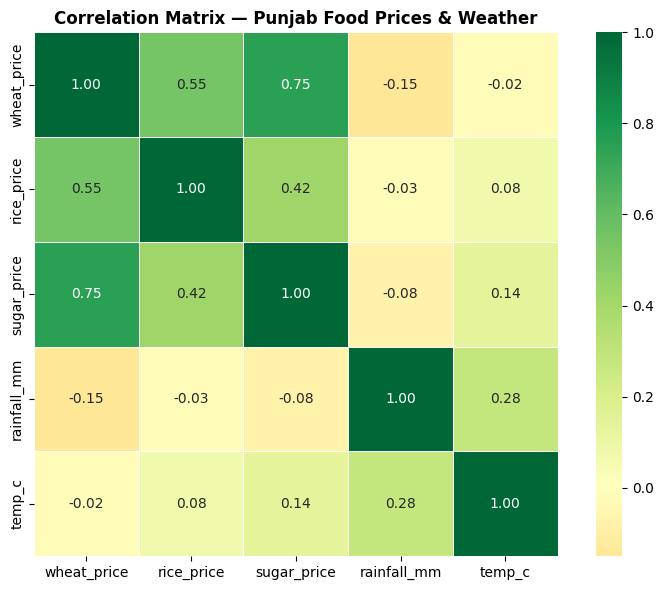

In [6]:
corr_matrix = df[['wheat_price', 'rice_price', 'sugar_price', 'rainfall_mm', 'temp_c']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Correlation Matrix — Punjab Food Prices & Weather', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
df = df.sort_values('date').reset_index(drop=True)

# --- Lag features (past prices as predictors) ---
for col in ['wheat_price', 'rice_price', 'sugar_price']:
    df[f'{col}_lag1'] = df[col].shift(1)   # 1 month ago
    df[f'{col}_lag2'] = df[col].shift(2)   # 2 months ago
    df[f'{col}_lag4'] = df[col].shift(4)   # 4 months ago

# --- Rolling averages (trend signal) ---
for col in ['wheat_price', 'rice_price', 'sugar_price']:
    df[f'{col}_roll4'] = df[col].shift(1).rolling(4).mean()   # 4 month avg
    df[f'{col}_roll8'] = df[col].shift(1).rolling(8).mean()   # 8 month avg

# --- Price momentum (% change over last 2 months) ---
for col in ['wheat_price', 'rice_price', 'sugar_price']:
    df[f'{col}_momentum'] = df[col].shift(1).pct_change(2) * 100

# --- Weather lag (rainfall affects crops 4-6 weeks later) ---
df['rainfall_lag2'] = df['rainfall_mm'].shift(2)
df['rainfall_lag4'] = df['rainfall_mm'].shift(4)

# --- Season flags ---
df['month'] = df['date'].dt.month
df['is_summer'] = df['month'].isin([5, 6, 7, 8]).astype(int)
df['is_harvest'] = df['month'].isin([4, 5]).astype(int)      # wheat harvest
df['is_crushing'] = df['month'].isin([11, 12, 1, 2]).astype(int)  # sugarcane crushing

# --- Drop rows with NaN from lag/rolling (first 8 rows) ---
df_features = df.dropna().reset_index(drop=True)

print('Shape after feature engineering:', df_features.shape)
print('Total features:', df_features.shape[1])
print('\nNew columns added:')
print([c for c in df_features.columns if c not in ['date', 'wheat_price', 'rice_price', 'sugar_price', 'rainfall_mm', 'temp_c', 'month']])

Shape after feature engineering: (95, 31)
Total features: 31

New columns added:
['year', 'wheat_price_lag1', 'wheat_price_lag2', 'wheat_price_lag4', 'rice_price_lag1', 'rice_price_lag2', 'rice_price_lag4', 'sugar_price_lag1', 'sugar_price_lag2', 'sugar_price_lag4', 'wheat_price_roll4', 'wheat_price_roll8', 'rice_price_roll4', 'rice_price_roll8', 'sugar_price_roll4', 'sugar_price_roll8', 'wheat_price_momentum', 'rice_price_momentum', 'sugar_price_momentum', 'rainfall_lag2', 'rainfall_lag4', 'is_summer', 'is_harvest', 'is_crushing']


In [8]:
df_features.to_csv('../data/processed/punjab_food_prices_features.csv', index=False)
print('Feature dataset saved.')
print('Shape:', df_features.shape)

Feature dataset saved.
Shape: (95, 31)
